In [ ]:
import numpy as np

In [ ]:
x=np.random.randn(600,1000)
x

array([[-2.13666164, -0.25152018, -0.07657247, ...,  2.28809042,
        -0.12555684, -0.19686361],
       [-2.34105895, -0.01546342, -0.42951088, ..., -0.25354304,
         0.71974194,  1.25790197],
       [ 0.12758761,  0.44866707, -0.45363009, ..., -1.4282644 ,
         0.51149934,  2.13095878],
       ...,
       [-0.80755724,  0.12439214, -1.01100589, ...,  1.56519602,
        -0.20608451, -0.37583292],
       [-0.26032025,  0.0983753 , -1.27038233, ..., -0.04091959,
         0.89412558, -1.11254292],
       [-0.8460588 ,  0.12748107,  0.90786087, ...,  1.71841822,
         0.71383533,  1.59482003]])

In [ ]:
y=np.zeros((1000,5))

In [ ]:
labels=np.random.randint(0,5,1000)

In [ ]:
y[np.arange(1000),labels]=1
y

array([[0., 0., 1., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 1., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.]])

In [ ]:
w1=np.random.randn(30,600)
b1=np.random.randn(30,1)
w2=np.random.randn(20,30)
b2=np.random.randn(20,1)
w3=np.random.randn(5,20)
b3=np.random.randn(5,1)

In [ ]:
def relu(z):
  return np.maximum(0,z)
def tanh(z):
  return np.tanh(z)
def sigmoid(z):
  return 1/(1+np.exp(-z))
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=0, keepdims=True))
    return exp_z / np.sum(exp_z, axis=0, keepdims=True)
def tanh_deriv(z):
    return 1-np.power(z,2)

In [ ]:
def forward_pass(x):
  z1=w1@x+b1
  a1=tanh(z1)
  z2=w2@a1+b2
  a2=tanh(z2)
  z3=w3@a2+b3
  y_hat=softmax(z3)
  return z1,a1,z2,a2,z3,y_hat

In [ ]:
def compute_loss(y_hat, y):
    y = y.T
    m = y.shape[1]
    loss = -np.sum(y * np.log(y_hat + 1e-8)) / m
    return loss

In [ ]:
z1,a1,z2,a2,z3,y_hat = forward_pass(x)

loss = compute_loss(y_hat, y)

In [ ]:
print(loss)

5.681001215134251


In [ ]:
def backward_pass(x,y,z1,a1,z2,a2,z3,y_hat):
    m = x.shape[0]
    y = y.T

    # Output layer gradients
    dz3 = y_hat - y
    dw3 = (1/m) * dz3 @ a2.T
    db3 = (1/m) * np.sum(dz3, axis=1, keepdims=True)

    # hidden layer gradients
    da2 = w3.T @ dz3
    dz2 = da2 * tanh_deriv(a2)
    dw2 = (1/m) * dz2 @ a1.T
    db2 = (1/m) * np.sum(dz2, axis=1, keepdims=True)

    # Hidden layer gradients
    da1 = w2.T @ dz2
    dz1 = da1 * tanh_deriv(a1)
    dw1 = (1/m) * dz1 @ x.T
    db1 = (1/m) * np.sum(dz1, axis=1, keepdims=True)

    return dw1,db1,dw2,db2,dw3,db3

In [ ]:
def update_parameters(w1, b1, w2, b2,w3,b3, dw1, db1, dw2, db2,dw3,db3, lr=0.01):
    w1 = w1 - lr * dw1
    b1 = b1 - lr * db1
    w2 = w2 - lr * dw2
    b2 = b2 - lr * db2
    w3 = w3 - lr * dw3
    b3 = b3 - lr * db3
    return w1, b1, w2, b2,w3,b3

In [ ]:
epochs = 50
losses = []
for i in range(epochs):
    # Forward
    z1, a1, z2,a2,z3,y_hat = forward_pass(x)

    # Loss
    loss = compute_loss(y_hat, y)
    losses.append(loss)

    # Backward
    dw1,db1,dw2,db2,dw3,db3= backward_pass(x,y,z1,a1,z2,a2,z3,y_hat)

    # Update
    w1, b1, w2, b2,w3,b3= update_parameters(w1, b1, w2, b2,w3,b3, dw1, db1, dw2, db2,dw3,db3)

    if i % 10 == 0:
        print(f"Epoch {i}, Loss: {loss}")

Epoch 0, Loss: 5.681001215134251
Epoch 10, Loss: 5.403229376184392
Epoch 20, Loss: 5.178728991971563
Epoch 30, Loss: 4.989827612092608
Epoch 40, Loss: 4.809335357281276


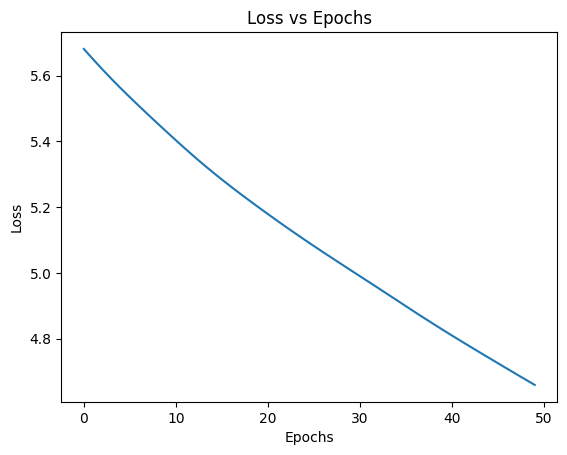

In [ ]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()